# Week 02: Analytical Methods & Neural Networks - Homework Solutions
## MECE6313E: Advanced Heat Transfer

**Solutions Set**

This notebook contains the solutions to the homework problems on analytical methods and neural networks. It provides detailed derivations, code implementations, and discussions.

---

## Problem 2: Integral Transforms (Laplace Transform)

### Analytical Derivation

**1. Laplacian Domain:**
Apply $\mathcal{L}$ to $\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}$:
$$ s\bar{T}(x,s) - T(x,0) = \alpha \frac{d^2 \bar{T}}{dx^2} $$
With $T(x,0) = T_0 = 25$:
$$ \frac{d^2 \bar{T}}{dx^2} - \frac{s}{\alpha}\bar{T} = -\frac{T_0}{\alpha} $$

**2. General Solution in s-domain:**
Homogeneous solution: $\bar{T}_h = A e^{-qx} + B e^{qx}$, where $q = \sqrt{s/\alpha}$.
Particular part: $\bar{T}_p = T_0/s$.
$$ \bar{T}(x,s) = A e^{-\sqrt{s/\alpha}x} + B e^{\sqrt{s/\alpha}x} + \frac{T_0}{s} $$

**3. Boundary Conditions:**
- As $x \to \infty$, $T$ is bounded $\implies B = 0$.
- At $x=0$, $T(0,t) = T_{boundary} = 100$. In Laplace domain: $\bar{T}(0,s) = 100/s$.
$$ A + \frac{T_0}{s} = \frac{100}{s} \implies A = \frac{100 - T_0}{s} $$
So, $\bar{T}(x,s) = \frac{T_0}{s} + \frac{T_{boundary} - T_0}{s} e^{-\sqrt{s/\alpha}x}$.

**4. Inverse Transform:**
Using the table pair: $\mathcal{L}^{-1}\left\{ \frac{e^{-k\sqrt{s}}}{s} \right\} = \text{erfc}\left(\frac{k}{2\sqrt{t}}\right)$.
Here $k = x/\sqrt{\alpha}$.
$$ T(x,t) = T_0 + (T_{boundary} - T_0) \text{erfc}\left(\frac{x}{2\sqrt{\alpha t}}\right) $$

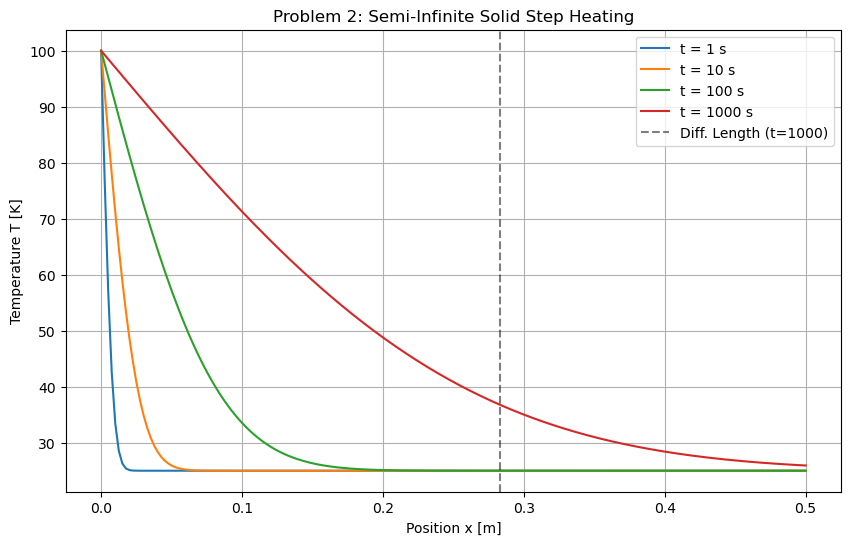

In [ ]:
from scipy.special import erfc

# Parameters
T0 = 25  # K
T_boundary = 100  # K
alpha = 2e-5  # m^2/s

def laplace_solution(x, t):
    if t == 0:
        return np.full_like(x, T0)
    eta = x / (2 * np.sqrt(alpha * t))
    return T0 + (T_boundary - T0) * erfc(eta)

x = np.linspace(0, 0.5, 200)
times_p2 = [1, 10, 100, 1000]

plt.figure(figsize=(10, 6))
for t in times_p2:
    T_vals = laplace_solution(x, t)
    plt.plot(x, T_vals, label=f't = {t} s')

# Plot diffusion length approximation for t=1000
t_ref = 1000
delta = 2 * np.sqrt(alpha * t_ref)
T_delta = T0 + (T_boundary - T0) * erfc(delta / (2 * np.sqrt(alpha * t_ref)))
# Note: erfc(1) approx 0.157, so T drops significantly
plt.axvline(delta, color='k', linestyle='--', alpha=0.5, label=f'Diff. Length (t={t_ref})')

plt.xlabel('Position x [m]')
plt.ylabel('Temperature T [K]')
plt.title('Problem 2: Semi-Infinite Solid Step Heating')
plt.legend()
plt.grid(True)
plt.show()

### Discussion (Problem 2)
- **Diffusion Length:** The diffusion length $\delta \approx 2\sqrt{\alpha t}$ characterizes the depth of thermal penetration. At this depth, the argument of the erfc function is 1, and $\text{erfc}(1) \approx 0.157$. Thus, the temperature rise is only about 16% of the surface temperature rise.
- **Speed:** The "thermal front" moves proportionally to $\sqrt{t}$, which indicates a diffusive process rather than a wave-like propagation (which would be proportional to $t$). Heat penetration slows down as time progresses.

---